# DAV LAB ASSIGNMENT - 2

## Name: k.spurthi
## Enroll no: 2503A52142




---




# Import Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("earthquake_1995-2023.csv")

print(df.shape)
df.head()

(1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


## 📊 Bar Graph
Top 10 Countries with Earthquakes

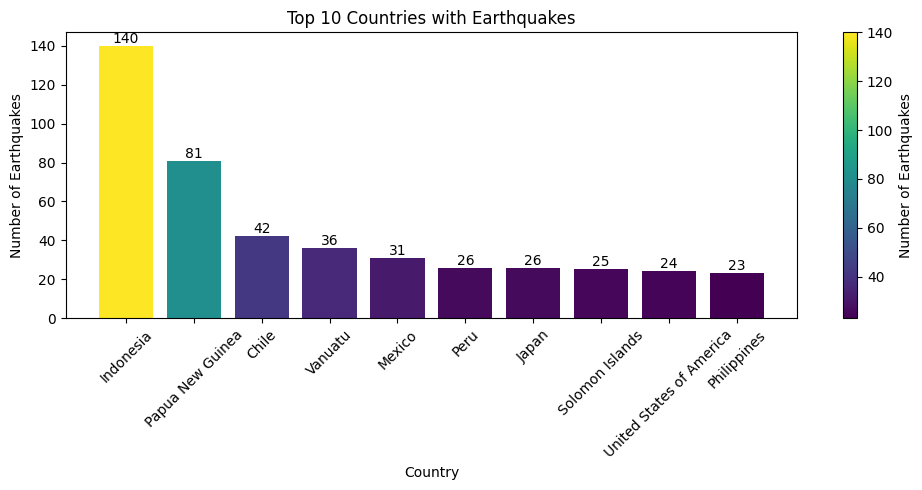

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

country_count = df['country'].value_counts().head(10)

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 5))

# Normalize earthquake counts
norm = colors.Normalize(
    vmin=country_count.min(),
    vmax=country_count.max()
)

# Create colors based on number of earthquakes
bar_colors = cm.viridis(norm(country_count.values))

# Create bars
bars = ax.bar(
    country_count.index,
    country_count.values,
    color=bar_colors
)

# Titles and labels
ax.set_title('Top 10 Countries with Earthquakes')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Earthquakes')
ax.tick_params(axis='x', rotation=45)

# Display values on top of bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

# Add color map
sm = cm.ScalarMappable(norm=norm, cmap='viridis')
sm.set_array(country_count.values)

fig.colorbar(
    sm,
    ax=ax,
    label='Number of Earthquakes'
)

plt.tight_layout()
plt.show()

**Conclusion:**

The bar graph shows that some countries have significantly more recorded earthquakes than others. It helps identify the countries with the highest number of earthquakes in the dataset.

## 📊 Grouped Bar Graph
Earthquake Alerts by Continent

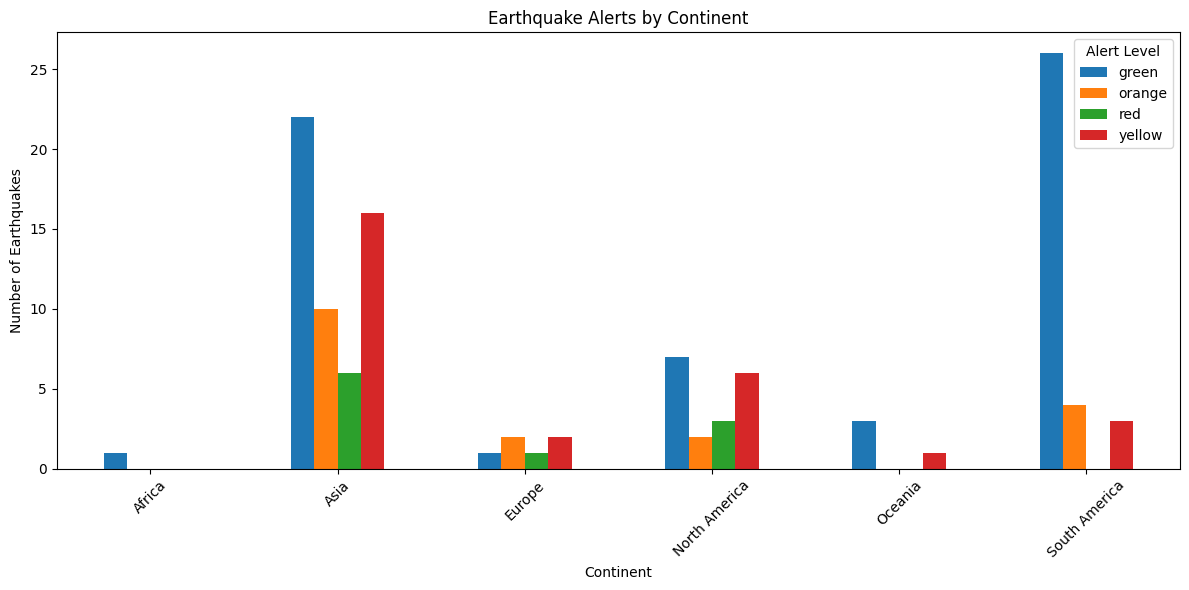

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.crosstab(df['continent'], df['alert'])

data.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Earthquake Alerts by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45)
plt.legend(title='Alert Level')

plt.tight_layout()
plt.show()

**Conclusion:**

The grouped bar graph compares different earthquake alert levels across continents. It shows that the distribution of alert levels varies between continents, allowing us to compare the number of earthquakes under each alert category.

## 📊 Stacked Bar Graph
Earthquake Alerts by Continent

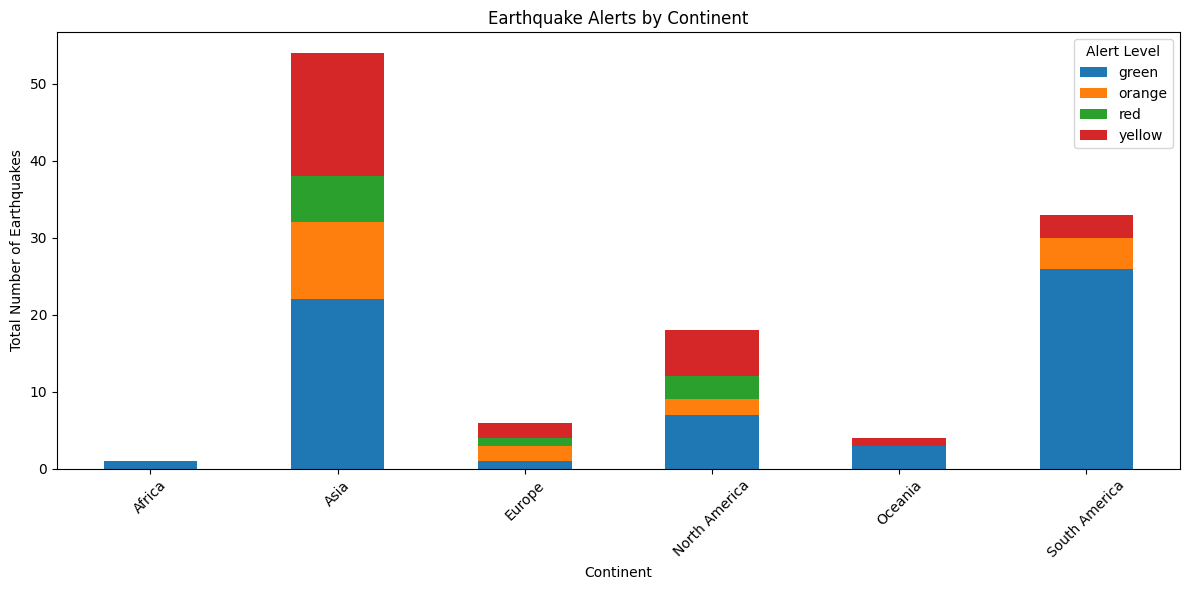

In [ ]:
data = pd.crosstab(df['continent'], df['alert'])

data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Earthquake Alerts by Continent')
plt.xlabel('Continent')
plt.ylabel('Total Number of Earthquakes')
plt.xticks(rotation=45)
plt.legend(title='Alert Level')

plt.tight_layout()
plt.show()

**Conclusion:**

The stacked bar graph shows the total earthquake records for each continent while also showing how different alert levels contribute to that total. It helps us understand the overall composition of earthquake alerts within each continent.

## 📈 Histogram
Distribution of Earthquake Magnitudes

Number of Bins: 10
Bin Size / Width: 0.26

Bin Range		Frequency
--------------------------------
6.50 - 6.76		436
6.76 - 7.02		261
7.02 - 7.28		103
7.28 - 7.54		84
7.54 - 7.80		49
7.80 - 8.06		43
8.06 - 8.32		17
8.32 - 8.58		2
8.58 - 8.84		3
8.84 - 9.10		2


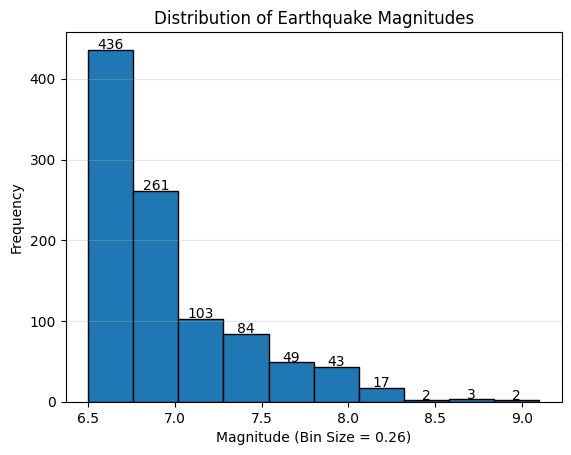

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Remove missing values
magnitude = df['magnitude'].dropna()

# Number of bins
num_bins = 10

# Minimum and maximum magnitude
min_mag = magnitude.min()
max_mag = magnitude.max()

# Bin size
bin_width = (max_mag - min_mag) / num_bins

# Create histogram
frequency, bins, patches = plt.hist(
    magnitude,
    bins=num_bins,
    edgecolor='black'
)

print("Number of Bins:", num_bins)
print("Bin Size / Width:", round(bin_width, 2))

print("\nBin Range\t\tFrequency")
print("--------------------------------")

for i in range(len(frequency)):
    print(
        f"{bins[i]:.2f} - {bins[i+1]:.2f}\t\t{int(frequency[i])}"
    )

# Show frequency on bars
for i in range(len(frequency)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,
        frequency[i] + 1,
        str(int(frequency[i])),
        ha='center'
    )

plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel(f'Magnitude (Bin Size = {bin_width:.2f})')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)

plt.show()

**Conclusion:**

The histogram shows the distribution of earthquake magnitudes. Most earthquakes in the dataset are concentrated within certain magnitude ranges, while high-magnitude earthquakes occur less frequently.

## 🥧 Pie Chart
Earthquakes by Continent

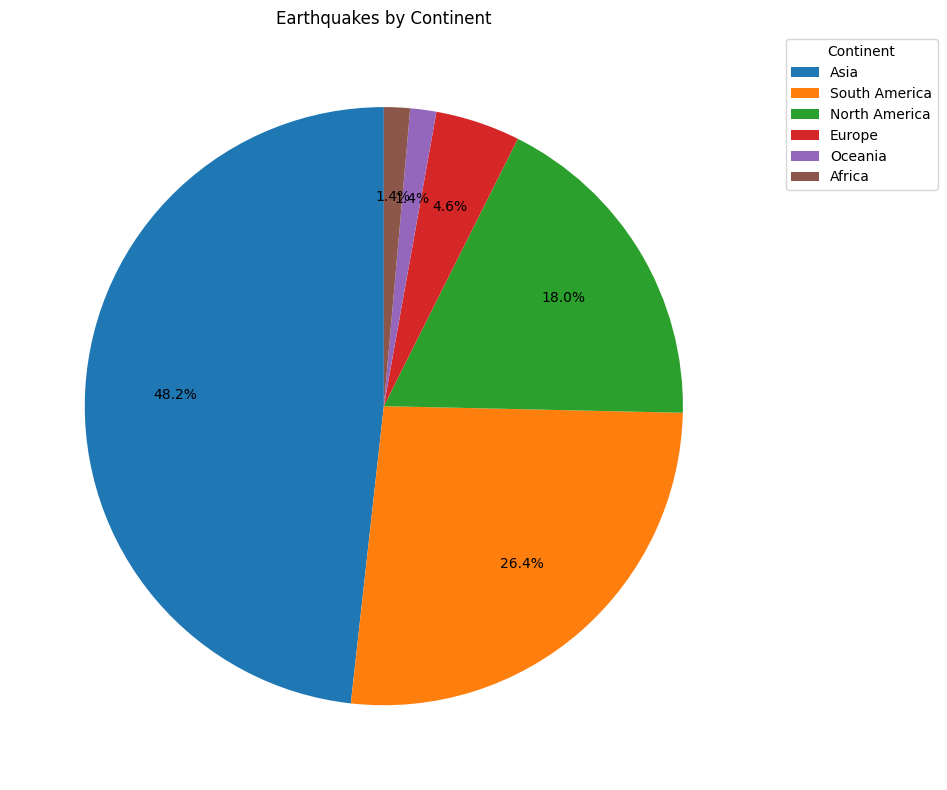

In [ ]:
import matplotlib.pyplot as plt

# Count earthquakes by continent
continent_count = df['continent'].value_counts()

# Create pie chart
fig, ax = plt.subplots(figsize=(9, 8))

wedges, texts, autotexts = ax.pie(
    continent_count,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7
)

# Legend with the matching colors and names
ax.legend(
    wedges,
    continent_count.index,
    title="Continent",
    loc="upper right",
    bbox_to_anchor=(1.25, 1)
)

ax.set_title("Earthquakes by Continent")

plt.tight_layout()
plt.show()

**Conclusion:**

The pie chart shows the percentage distribution of earthquakes across continents. Asia has the largest share in the dataset, followed by South America and North America, while the remaining continents contribute smaller shares.

## 🔵 Scatter Plot
Earthquake Magnitude vs Depth

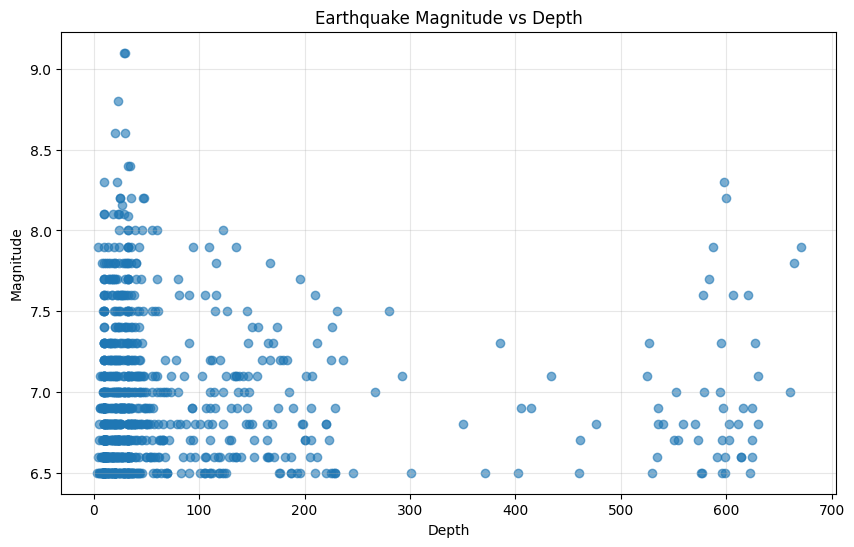

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df['depth'],
    df['magnitude'],
    alpha=0.6
)

plt.title('Earthquake Magnitude vs Depth')
plt.xlabel('Depth')
plt.ylabel('Magnitude')

plt.grid(alpha=0.3)

plt.show()

**Conclusion:**

The scatter plot shows the relationship between earthquake depth and magnitude. The points are spread across different depths and magnitudes, indicating that earthquake magnitude does not have a simple direct relationship with depth in this dataset.

## 📈 Line Plot
Number of Earthquakes per Year

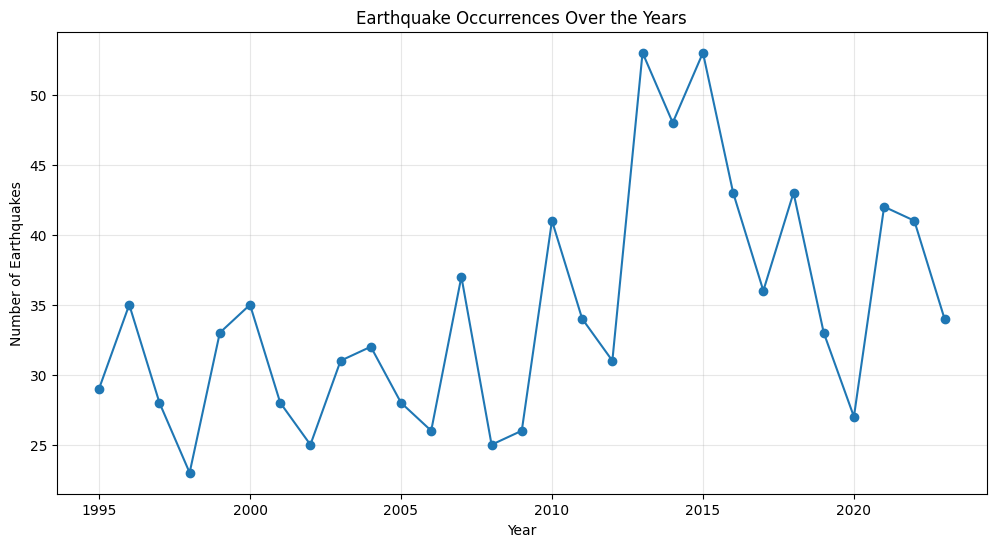

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True)

yearly_count = df['date_time'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_count.index,
    yearly_count.values,
    marker='o'
)

plt.title('Earthquake Occurrences Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')

plt.grid(alpha=0.3)

plt.show()

**Conclusion:**

The line plot shows how the number of recorded earthquakes changes over the years from 1995 to 2023. The number varies from year to year, showing fluctuations in the recorded earthquake activity.